In [16]:
#imports/dependencies
%pip install langgraph langchain langchain-openAI tavily-python graphviz matplotlib


Note: you may need to restart the kernel to use updated packages.


In [17]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [18]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
#create users, availability, appointments csvs
users_df = pd.DataFrame([
    {"user_id": "user_123", "patient_name": "Tendai Ball", "date_of_birth": "2003-01-01", "phone": "555-1234"},
    {"user_id": "user_456", "patient_name": "Jane Doe", "date_of_birth": "1998-07-10", "phone": "555-9876"},
    {"user_id": "user_789", "patient_name": "John Smith", "date_of_birth": "1985-11-22", "phone": "555-2468"}
])

availability_df = pd.DataFrame([
    {"date": "2026-04-15", "specialty": "cardiology",  "time": "9:00 AM",  "is_available": 1},
    {"date": "2026-04-15", "specialty": "cardiology",  "time": "1:30 PM",  "is_available": 1},
    {"date": "2026-04-15", "specialty": "dermatology", "time": "10:00 AM", "is_available": 1},
    {"date": "2026-04-15", "specialty": "dermatology", "time": "3:00 PM",  "is_available": 1},
    {"date": "2026-04-16", "specialty": "cardiology",  "time": "11:00 AM", "is_available": 1},
    {"date": "2026-04-16", "specialty": "neurology",   "time": "2:00 PM",  "is_available": 1}
])

appointments_df = pd.DataFrame([
    {
        "appointment_id": "APT-1001",
        "user_id": "user_123",
        "patient_name": "Tendai Ball",
        "date": "2026-04-15",
        "specialty": "cardiology",
        "time": "9:00 AM",
        "status": "booked"
    }
])

users_df.to_csv("users.csv", index=False)
availability_df.to_csv("availability.csv", index=False)
appointments_df.to_csv("appointments.csv", index=False)

print("Created users.csv, availability.csv, and appointments.csv")

Created users.csv, availability.csv, and appointments.csv


In [20]:
from dotenv import load_dotenv
import os

# Specify the full path to your .env file
load_dotenv(r"C:\Users\Tendai\OneDrive\Chat Agents\.env")
openai_api_key = os.getenv("OPENAI_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [21]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model = 'gpt-3.5-turbo', temperature=0, openai_api_key=openai_api_key)

In [99]:
#identify user tool
import pandas as pd
import re
from datetime import datetime
from langchain.tools import tool

@tool
def identify_user(name_or_phone: str) -> dict:
    """
    Identify an existing user by full name or phone number.
    """
    query = name_or_phone.strip()

    try:
        users = pd.read_csv("users.csv", dtype=str).fillna("")

        phone_matches = users[users["phone"] == query]
        if len(phone_matches) == 1:
            row = phone_matches.iloc[0]
            return {
                "status": "user_found",
                "user_id": row["user_id"],
                "patient_name": row["patient_name"],
                "date_of_birth": row["date_of_birth"],
                "phone": row["phone"],
            }
        elif len(phone_matches) > 1:
            return {
                "status": "multiple_users_found",
                "matches": phone_matches.to_dict(orient="records"),
            }

        exact_name_matches = users[
            users["patient_name"].str.lower() == query.lower()
        ]
        if len(exact_name_matches) == 1:
            row = exact_name_matches.iloc[0]
            return {
                "status": "user_found",
                "user_id": row["user_id"],
                "patient_name": row["patient_name"],
                "date_of_birth": row["date_of_birth"],
                "phone": row["phone"],
            }
        elif len(exact_name_matches) > 1:
            return {
                "status": "multiple_users_found",
                "matches": exact_name_matches.to_dict(orient="records"),
            }

        partial_name_matches = users[
            users["patient_name"].str.lower().str.contains(query.lower(), regex=False)
        ]
        if len(partial_name_matches) == 1:
            row = partial_name_matches.iloc[0]
            return {
                "status": "user_found",
                "user_id": row["user_id"],
                "patient_name": row["patient_name"],
                "date_of_birth": row["date_of_birth"],
                "phone": row["phone"],
            }
        elif len(partial_name_matches) > 1:
            return {
                "status": "multiple_users_found",
                "matches": partial_name_matches.to_dict(orient="records"),
            }

        return {
            "status": "user_not_found",
            "query": query,
        }

    except Exception as e:
        return {
            "status": "error",
            "message": str(e),
        }


def normalize_date_to_2026(date_str: str) -> str:
    if not isinstance(date_str, str):
        return date_str

    stripped = date_str.strip()
    md_match = re.fullmatch(r"(\d{1,2})[/-](\d{1,2})", stripped)
    if md_match:
        month = int(md_match.group(1))
        day = int(md_match.group(2))
        try:
            return datetime(2026, month, day).strftime("%Y-%m-%d")
        except ValueError:
            return stripped

    return stripped

@tool
def check_availability(date: str, specialty: str) -> dict:
    """
    Check available appointment times for a given specialty on a specific date.
    """
    try:
        if not isinstance(date, str) or not date.strip() or date.strip() == "0":
            date = normalize_date_to_2026(date)
            return {
                "status": "invalid_date",
                "message": "Date is missing or invalid. Please provide a valid appointment date.",
                "date": date,
                "specialty": specialty,
                "available_slots": [],
            }
        if not isinstance(specialty, str) or not specialty.strip():
            return {
                "status": "invalid_specialty",
                "message": "Specialty is missing or invalid. Please provide a valid specialty.",
                "date": date,
                "specialty": specialty,
                "available_slots": [],
            }

        availability = pd.read_csv("availability.csv", dtype=str).fillna("")

        filtered = availability[
            (availability["date"] == date) &
            (availability["specialty"].str.lower() == specialty.lower()) &
            (availability["is_available"].astype(str) == "1")
        ]

        slots = filtered["time"].tolist()

        if not slots:
            return {
                "status": "no_slots_available",
                "date": date,
                "specialty": specialty,
                "available_slots": [],
            }

        return {
            "status": "slots_found",
            "date": date,
            "specialty": specialty,
            "available_slots": slots,
        }

    except Exception as e:
        return {
            "status": "error",
            "message": str(e),
        }

# @tool
# def provide_availability_info(date: str, specialty: str) -> str:
#     """
#     Use when the user asks about available appointment timeslots for a specific date and/or specialty.
#     """

#     date = normalize_date_to_2026(date)
#     has_date = isinstance(date, str) and date.strip() and date.strip() != "0"
#     has_specialty = isinstance(specialty, str) and specialty.strip()

#     availability = pd.read_csv("availability.csv", dtype=str).fillna("")

#     if has_date and has_specialty:
#         availability_result = check_availability(date, specialty)
#         if availability_result["status"] == "slots_found":
#             slots = availability_result["available_slots"]
#             return f"Available slots for {specialty} on {date}: {', '.join(slots)}"
#         elif availability_result["status"] == "no_slots_available":
#             return f"No available slots for {specialty} on {date}."
#         elif availability_result["status"] in ["invalid_date", "invalid_specialty"]:
#             return availability_result["message"]
#         else:
#             return "An error occurred while checking availability."

#     if not has_date and not has_specialty:
#         return "Please provide either a date or a specialty to check availability."

#     if has_date:
#         filtered = availability[
#             (availability["date"] == date) &
#             (availability["is_available"].astype(str) == "1")
#         ]
#         specialties = filtered["specialty"].str.lower().sort_values().unique().tolist()
#         if not specialties:
#             return f"No available specialties on {date}."
#         return f"Available specialties on {date}: {', '.join(specialties)}"

#     if has_specialty:
#         filtered = availability[
#             (availability["specialty"].str.lower() == specialty.lower()) &
#             (availability["is_available"].astype(str) == "1")
#         ]
#         dates = filtered["date"].sort_values().unique().tolist()
#         if not dates:
#             return f"No available dates for {specialty}."
#         return f"Available dates for {specialty}: {', '.join(dates)}"

#     return "An error occurred while checking availability."

@tool
def book_appointment(user_id: str, patient_name: str, date: str, time: str, specialty: str) -> dict:
    """
    Book an appointment for an identified user, then update the CSV files.
    """
    try:
        date = normalize_date_to_2026(date)
        if not isinstance(date, str) or not date.strip() or date.strip() == "0":
            return {
                "status": "invalid_date",
                "message": "Date is missing or invalid. Please provide a valid appointment date.",
                "user_id": user_id,
                "patient_name": patient_name,
                "date": date,
                "time": time,
                "specialty": specialty,
            }
        if not isinstance(time, str) or not time.strip() or time.strip() == "0":
            return {
                "status": "invalid_time",
                "message": "Time is missing or invalid. Please provide a valid appointment time.",
                "user_id": user_id,
                "patient_name": patient_name,
                "date": date,
                "time": time,
                "specialty": specialty,
            }
        if not isinstance(specialty, str) or not specialty.strip():
            return {
                "status": "invalid_specialty",
                "message": "Specialty is missing or invalid. Please provide a valid specialty.",
                "user_id": user_id,
                "patient_name": patient_name,
                "date": date,
                "time": time,
                "specialty": specialty,
            }
        if not isinstance(patient_name, str) or not patient_name.strip():
            return {
                "status": "invalid_patient_name",
                "message": "Patient name is missing or invalid. Please provide a valid patient name.",
                "user_id": user_id,
                "patient_name": patient_name,
                "date": date,
                "time": time,
                "specialty": specialty,
            }

        availability = pd.read_csv("availability.csv", dtype=str).fillna("")
        appointments = pd.read_csv("appointments.csv", dtype=str).fillna("")

        # Find matching available slot
        slot_mask = (
            (availability["date"] == date) &
            (availability["specialty"].str.lower() == specialty.lower()) &
            (availability["time"] == time) &
            (availability["is_available"].astype(str) == "1")
        )

        if slot_mask.sum() == 0:
            return {
                "status": "slot_not_available",
                "user_id": user_id,
                "patient_name": patient_name,
                "date": date,
                "time": time,
                "specialty": specialty,
            }

        # Create new appointment ID
        if len(appointments) == 0:
            new_id_num = 1001
        else:
            existing_ids = appointments["appointment_id"].str.replace("APT-", "", regex=False)
            existing_ids = pd.to_numeric(existing_ids, errors="coerce").dropna()
            new_id_num = int(existing_ids.max()) + 1 if len(existing_ids) > 0 else 1001

        appointment_id = f"APT-{new_id_num}"

        # Append new appointment
        new_row = pd.DataFrame([{
            "appointment_id": appointment_id,
            "user_id": user_id,
            "patient_name": patient_name,
            "date": date,
            "specialty": specialty,
            "time": time,
            "status": "booked"
        }])

        appointments = pd.concat([appointments, new_row], ignore_index=True)

        # Mark slot unavailable
        availability.loc[slot_mask, "is_available"] = "0"

        # Save both files
        appointments.to_csv("appointments.csv", index=False)
        availability.to_csv("availability.csv", index=False)

        return {
            "status": "booking_confirmed",
            "appointment_id": appointment_id,
            "user_id": user_id,
            "patient_name": patient_name,
            "date": date,
            "time": time,
            "specialty": specialty,
        }

    except Exception as e:
        return {
            "status": "error",
            "message": str(e),
        }


In [100]:
#bind tools
tools = [identify_user, check_availability, book_appointment]
toolsbyname = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [101]:
#build nodes
from typing import Literal
import json
from langgraph.graph import MessagesState, START, END, StateGraph
from langchain_core.messages import ToolMessage, SystemMessage, HumanMessage
#initialize assistant system message
ASSISTANT_SYSTEM_MESSAGE = SystemMessage(content="You are a scheduling assistant. " \
"Do not guess missing appointment information. " \
"If the user has not provided a date, time, patient name, or specialty, ask a follow-up question to get that information before taking any booking action. " \
"Ask only one follow-up question at a time, but ask as many follow-ups as necessary until all required details are present. " \
"Do not invent dates or assume defaults. Do not give medical advice.")

def llm_call (state:MessagesState):
    """llm decides whether to call tool or not using messages state"""
    return {
        "messages": [llm_with_tools.invoke(
            [ASSISTANT_SYSTEM_MESSAGE] + state["messages"]
        )]
    }
def tool_node(state: dict):
    """performs tool call"""
    result = []

    for tool_call in state["messages"][-1].tool_calls:
        tool = toolsbyname[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])

        if isinstance(observation, dict):
            observation = json.dumps(observation, indent=2)
        else:
            observation = str(observation)

        result.append(
            ToolMessage(
                content=observation,
                tool_call_id=tool_call["id"]
            )
        )

    return {"messages": result}

def should_continue(state: MessagesState) -> Literal["action", END]:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "action"
    return END

In [102]:
from langgraph.checkpoint.memory import InMemorySaver
#build agent
agent_builder = StateGraph(MessagesState)
#add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)
#add edges
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "action":"environment",
        END: END
    }
)
agent_builder.add_edge("environment", "llm_call")
#compile
memory = InMemorySaver()
agent = agent_builder.compile(checkpointer=memory)

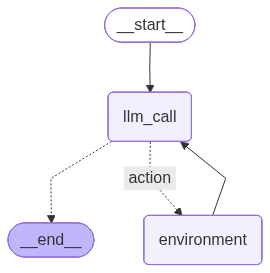

In [103]:
#display
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [104]:
from datetime import datetime
from pathlib import Path


SETTINGS = {
    "default_save_path": "conversation.json"
}

def serialize_message(msg):
    return {
        "type": msg.__class__.__name__,
        "content": str(msg.content),
    }

def save_thread_to_file(thread_id: str, save_path: str | None = None):
    path = save_path or f"{thread_id}.json"

    config = {"configurable": {"thread_id": thread_id}}
    state = agent.get_state(config).values

    payload = {
        "thread_id": thread_id,
        "messages": [serialize_message(m) for m in state["messages"]],
    }

    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)
        
def chat(thread_id: str, user_text: str, save_path: str | None = None):
    config = {"configurable": {"thread_id": thread_id}}

    response = agent.invoke(
        {"messages": [HumanMessage(content=user_text)]},
        config=config
    )

    save_thread_to_file(thread_id, save_path)
    print(response["messages"][-1].content)

In [105]:
chat("thread_1", "Summarize our conversation so far")

You are looking to book an appointment, but we have not yet determined the date, time, patient name, or specialty for the appointment. How can I assist you further?


In [111]:
chat("thread_2", "I would like to book an appointment with a cardiologist for Jane Doe on April 15th at 11 AM.")

I'm sorry, but the appointment slot for Jane Doe on April 15th at 11 AM is not available. Would you like to choose a different date or time?
